<a href="https://colab.research.google.com/github/chrimapaul/Heart_Disease_Prediction_Group6/blob/main/Group6_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease.csv to heart_disease.csv


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

In [6]:
df=pd.read_csv('heart_disease.csv')

In [7]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [9]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [10]:
df.shape

(10000, 21)

data cleaning

missing values

In [11]:
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.inspection import permutation_importance

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [12]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage Missing": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing)

,Missing Values,Percentage Missing
Alcohol Consumption,2586,25.86
Diabetes,30,0.30
Sugar Consumption,30,0.30
Cholesterol Level,30,0.30
Age,29,0.29
Triglyceride Level,26,0.26
CRP Level,26,0.26
High LDL Cholesterol,26,0.26
High Blood Pressure,26,0.26
Low HDL Cholesterol,25,0.25


In [13]:
print(df["Heart Disease Status"].value_counts())

print("\nPercentage distribution:")
print(
    df["Heart Disease Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Percentage distribution:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


checking target distribution

In [14]:
print(df["Heart Disease Status"].value_counts())

print("\nPercentage distribution:")
print(
    df["Heart Disease Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

Percentage distribution:
Heart Disease Status
No     80.0
Yes    20.0
Name: proportion, dtype: float64


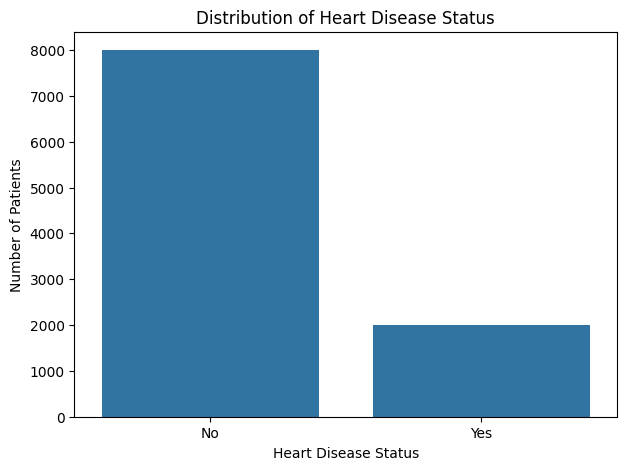

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Heart Disease Status"
)

plt.title("Distribution of Heart Disease Status")
plt.xlabel("Heart Disease Status")
plt.ylabel("Number of Patients")

plt.show()

Separating features and target

In [16]:
TARGET = "Heart Disease Status"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget classes:")
print(y.unique())

Features: (10000, 20)
Target: (10000,)

Target classes:
['No' 'Yes']


Converting the target to binary

In [17]:
y = y.map({
    "No": 0,
    "Yes": 1
})

print(y.value_counts())

Heart Disease Status
0    8000
1    2000
Name: count, dtype: int64


Identify numerical and categorical columns

In [18]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']

Categorical features:
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

Number of numerical features: 9
Number of categorical features: 11


training and splitting

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (8000, 20)
Testing set: (2000, 20)

Training target distribution:
Heart Disease Status
0    0.8
1    0.2
Name: proportion, dtype: float64

Testing target distribution:
Heart Disease Status
0    0.8
1    0.2
Name: proportion, dtype: float64


Create leakage-safe preprocessing

In [20]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Leakage-safe preprocessing pipeline created.")

Leakage-safe preprocessing pipeline created.


Baseline model

In [21]:
from sklearn.dummy import DummyClassifier

baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("Baseline Accuracy:",
      accuracy_score(y_test, baseline_pred))

print("\nBaseline Classification Report:")
print(
    classification_report(
        y_test,
        baseline_pred,
        target_names=["No Disease", "Disease"]
    )
)

Baseline Accuracy: 0.8

Baseline Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



Model 1: Logistic Regression

In [22]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION")
print("=" * 50)

print(
    classification_report(
        y_test,
        logistic_pred,
        target_names=["No Disease", "Disease"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test, logistic_prob))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

ROC-AUC: 0.48630312499999995


Model 2: Decision Tree

In [23]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=6,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42
            )
        )
    ]
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)
tree_prob = tree_model.predict_proba(X_test)[:, 1]

print("DECISION TREE")
print("=" * 50)

print(
    classification_report(
        y_test,
        tree_pred,
        target_names=["No Disease", "Disease"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test, tree_prob))

DECISION TREE
              precision    recall  f1-score   support

  No Disease       0.80      0.99      0.88      1600
     Disease       0.29      0.02      0.04       400

    accuracy                           0.79      2000
   macro avg       0.55      0.50      0.46      2000
weighted avg       0.70      0.79      0.72      2000

ROC-AUC: 0.517125


Model 3: K-Nearest Neighbours

In [24]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            KNeighborsClassifier(
                n_neighbors=7,
                weights="distance"
            )
        )
    ]
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

print("K-NEAREST NEIGHBOURS")
print("=" * 50)

print(
    classification_report(
        y_test,
        knn_pred,
        target_names=["No Disease", "Disease"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test, knn_prob))

K-NEAREST NEIGHBOURS
              precision    recall  f1-score   support

  No Disease       0.80      0.96      0.87      1600
     Disease       0.14      0.03      0.04       400

    accuracy                           0.77      2000
   macro avg       0.47      0.49      0.46      2000
weighted avg       0.67      0.77      0.71      2000

ROC-AUC: 0.506509375


Model 4: Random Forest

In [25]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_split=10,
                min_samples_leaf=4,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print("=" * 50)

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["No Disease", "Disease"]
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test, rf_prob))

RANDOM FOREST
              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

ROC-AUC: 0.5041296875


Cross-validation for ALL models

In [26]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "KNN": knn_model,
    "Random Forest": rf_model,
    }

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = {}

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results[name] = {
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    }

cv_results_df = pd.DataFrame(cv_results).T

display(
    cv_results_df.sort_values(
        by="ROC-AUC Mean",
        ascending=False
    ).round(4)
)


,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
Logistic Regression,0.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5115,0.0221
KNN,0.7844,0.0046,0.2569,0.0782,0.0419,0.0135,0.0719,0.0229,0.5069,0.0186
Random Forest,0.8000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5018,0.0194
Decision Tree,0.7931,0.0015,0.2098,0.0788,0.0131,0.0061,0.0247,0.0112,0.5001,0.0167


Compare models on the test set

In [27]:
test_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

test_results_df = pd.DataFrame(test_results)

display(
    test_results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    ).round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Decision Tree,0.7935,0.2903,0.0225,0.0418,0.5171
2,KNN,0.7740,0.1389,0.0250,0.0424,0.5065
3,Random Forest,0.8000,0.0000,0.0000,0.0000,0.5041
0,Logistic Regression,0.8000,0.0000,0.0000,0.0000,0.4863


Tuning the two strongest models

Random Forest tuning

In [29]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=2
            )
        )
    ]
)

rf_param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [5, 10, 15, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

rf_grid = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_iter=10,
    n_jobs=2,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV ROC-AUC:")
print(rf_grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Random Forest parameters:
{'classifier__n_estimators': 50, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_depth': 10}

Best Random Forest CV ROC-AUC:
0.50728076171875


Tune Gradient Boosting

In [30]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

gb_param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__min_samples_split": [2, 5, 10]
}

gb_grid = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_iter=10,
    n_jobs=2,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print("\nBest Gradient Boosting CV ROC-AUC:")
print(gb_grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Gradient Boosting parameters:
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__max_depth': 2, 'classifier__learning_rate': 0.01}

Best Gradient Boosting CV ROC-AUC:
0.5103403320312501


Evaluating the tuned models

In [31]:
tuned_models = {
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():

    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)

display(
    tuned_results_df.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Tuned Random Forest,0.8,0.0,0.0,0.0,0.5157
1,Tuned Gradient Boosting,0.8,0.0,0.0,0.0,0.4845


Final model comparison

In [32]:
all_results = pd.concat(
    [
        test_results_df,
        tuned_results_df
    ],
    ignore_index=True
)

all_results = all_results.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(
    all_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
1,Decision Tree,0.7935,0.2903,0.0225,0.0418,0.5171
4,Tuned Random Forest,0.8000,0.0000,0.0000,0.0000,0.5157
2,KNN,0.7740,0.1389,0.0250,0.0424,0.5065
3,Random Forest,0.8000,0.0000,0.0000,0.0000,0.5041
0,Logistic Regression,0.8000,0.0000,0.0000,0.0000,0.4863
5,Tuned Gradient Boosting,0.8000,0.0000,0.0000,0.0000,0.4845


Cross-validation of tuned models

In [33]:
tuned_cv_results = []

for name, model in tuned_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    tuned_cv_results.append({
        "Model": name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std()
    })

tuned_cv_df = pd.DataFrame(tuned_cv_results)

display(
    tuned_cv_df.round(4)
)

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,ROC-AUC Mean,ROC-AUC Std
0,Tuned Random Forest,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5073,0.0072
1,Tuned Gradient Boosting,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5103,0.0266


Confusion matrix for final candidate

In [34]:
best_model_name = tuned_results_df.loc[
    tuned_results_df["ROC-AUC"].idxmax(),
    "Model"
]

best_model = tuned_models[best_model_name]

print("Selected final candidate:", best_model_name)

Selected final candidate: Tuned Random Forest


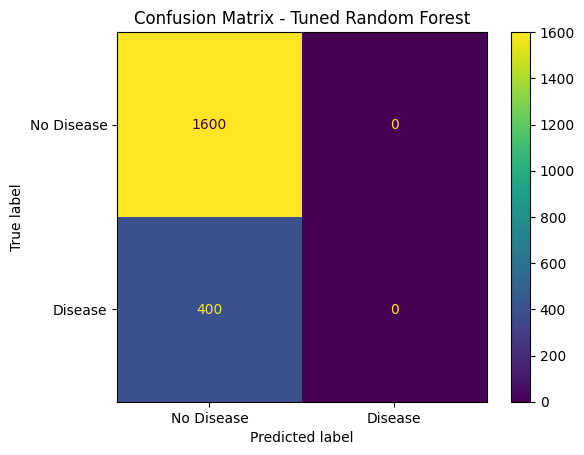

In [35]:
best_pred = best_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    best_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.show()

Full classification report

In [36]:
print(
    classification_report(
        y_test,
        best_pred,
        target_names=[
            "No Disease",
            "Disease"
        ]
    )
)

              precision    recall  f1-score   support

  No Disease       0.80      1.00      0.89      1600
     Disease       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



ROC curve

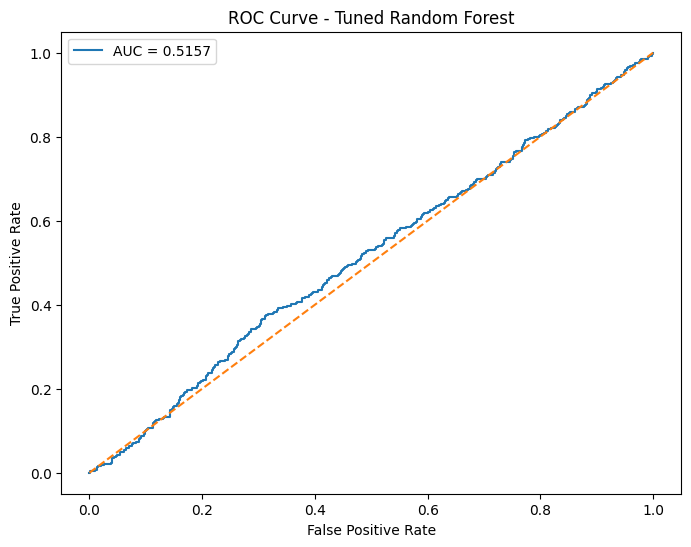

In [37]:
best_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    best_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    f"ROC Curve - {best_model_name}"
)

plt.legend()

plt.show()